# 🍕 CalorieSnap — EfficientNetV2B0 (최종)

| 항목 | 내용 |
|------|------|
| 모델 | EfficientNetV2B0 (keras.applications) |
| 입력 | 224×224×3 / 127.5 - 1.0 → [-1, 1] |
| 증강 | CenterCrop + Rotation + CutOut + ColorJitter |
| 학습 | 2-Stage (헤드 → 전체 파인튜닝 + Cosine LR) |
| 변환 | TFLite Float16 (~14MB) |

⚠️ **런타임 → 런타임 유형 변경 → T4 GPU 선택**

## 1️⃣ 환경 설치

In [ ]:
!pip install -q tensorflow-datasets>=4.9 matplotlib seaborn scikit-learn
print('✅ 설치 완료')

✅ 설치 완료


In [ ]:
import os, json, shutil, time
import numpy as np
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Google Drive 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/CalorieSnap_final'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'저장 경로: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
저장 경로: /content/drive/MyDrive/CalorieSnap_final


## 3️⃣ 설정

In [ ]:
SELECTED_CLASSES = [
    'pizza', 'hamburger', 'fried_rice', 'ramen', 'sushi',
    'steak', 'donuts', 'ice_cream', 'chicken_wings',
    'spaghetti_bolognese', 'spaghetti_carbonara', 'cup_cakes',
    'french_toast', 'risotto', 'macaroni_and_cheese',
    'grilled_salmon', 'bibimbap', 'miso_soup', 'tacos', 'chocolate_cake',
]

NUM_CLASSES   = len(SELECTED_CLASSES)  # 20
IMG_SIZE      = 224
BATCH_SIZE    = 32
SEED          = 42

# ── 학습 설정 ──────────────────────────────────────────────────
STAGE1_EPOCHS = 5      # 헤드만 학습 (backbone 동결)
STAGE2_EPOCHS = 25     # 전체 파인튜닝 (MobileNetV3: 20 → 25)
STAGE1_LR     = 1e-3
STAGE2_LR     = 5e-5   # 전체 파인튜닝 시 낮은 LR (1e-4 → 5e-5)

print(f'클래스 수: {NUM_CLASSES}')
for i, c in enumerate(SELECTED_CLASSES):
    print(f'  {i:2d}. {c}')

클래스 수: 20
   0. pizza
   1. hamburger
   2. fried_rice
   3. ramen
   4. sushi
   5. steak
   6. donuts
   7. ice_cream
   8. chicken_wings
   9. spaghetti_bolognese
  10. spaghetti_carbonara
  11. cup_cakes
  12. french_toast
  13. risotto
  14. macaroni_and_cheese
  15. grilled_salmon
  16. bibimbap
  17. miso_soup
  18. tacos
  19. chocolate_cake


## 4️⃣ Food-101 로드 & 필터링

In [ ]:
print('Food-101 로드 중 (최초 실행 시 ~20분)...')
(ds_train_full, ds_val_full, ds_test_full), info = tfds.load(
    'food101',
    split=['train[:80%]', 'train[80%:]', 'validation'],
    with_info=True,
    as_supervised=True,
)

all_class_names = info.features['label'].names

class_to_original_idx = {
    cls: all_class_names.index(cls) for cls in SELECTED_CLASSES
}
original_idx_to_new = {
    orig: new
    for new, (_, orig) in enumerate(class_to_original_idx.items())
}
valid_original_indices = list(class_to_original_idx.values())

print(f'\nFood-101 전체 클래스: {len(all_class_names)}')
print('✅ 20개 클래스 모두 확인됨')
for new_idx, cls in enumerate(SELECTED_CLASSES):
    print(f'  {new_idx:2d}. {cls:<25} (food101 idx: {class_to_original_idx[cls]})')

Food-101 로드 중 (최초 실행 시 ~20분)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.ISKL21_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.ISKL21_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.

Food-101 전체 클래스: 101
✅ 20개 클래스 모두 확인됨
   0. pizza                     (food101 idx: 76)
   1. hamburger                 (food101 idx: 53)
   2. fried_rice                (food101 idx: 44)
   3. ramen                     (food101 idx: 81)
   4. sushi                     (food101 idx: 95)
   5. steak                     (food101 idx: 93)
   6. donuts                    (food101 idx: 31)
   7. ice_cream                 (food101 idx: 58)
   8. chicken_wings             (food101 idx: 20)
   9. spaghetti_bolognese       (food101 idx: 90)
  10. spaghetti_carbonara       (food101 idx: 91)
  11. cup_cakes                 (food101 idx: 29)
  12. french_toast              (food101 idx: 42)
  13. risotto                   (food101 idx: 84)
  14. macaroni_and_cheese       (food101 idx: 62)
  15. grilled_salmon            (food101 idx: 50)
  16. bibimbap                  (food1

In [ ]:
def filter_fn(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int32), valid_original_indices))

def remap_fn(image, label):
    orig_keys  = tf.constant(list(original_idx_to_new.keys()),   dtype=tf.int32)
    new_vals   = tf.constant(list(original_idx_to_new.values()), dtype=tf.int32)
    label_int  = tf.cast(label, tf.int32)
    new_label  = tf.reduce_sum(
        tf.where(tf.equal(orig_keys, label_int), new_vals, tf.zeros_like(new_vals))
    )
    return image, tf.cast(new_label, tf.int32)

ds_train_filtered = ds_train_full.filter(filter_fn).map(remap_fn)
ds_val_filtered   = ds_val_full.filter(filter_fn).map(remap_fn)
ds_test_filtered  = ds_test_full.filter(filter_fn).map(remap_fn)

print('샘플 수 카운트 중...')
n_train = sum(1 for _ in ds_train_filtered)
n_val   = sum(1 for _ in ds_val_filtered)
n_test  = sum(1 for _ in ds_test_filtered)
print(f'Train: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}')

샘플 수 카운트 중...
Train: 12,029  |  Val: 2,971  |  Test: 5,000


## 5️⃣ 전처리 & 데이터 증강

**개선된 증강 목록**
- CenterCrop — 비율 유지 (Flutter와 동일)
- RandomRotation — 90° 단위 회전 (다양한 촬영 각도 대응)
- RandomFlip — 좌우 반전
- ColorJitter — 밝기 / 대비 / 채도
- **CutOut** — 랜덤 영역 마스킹 (유사 클래스 과적합 방지)
- 정규화 — `/ 127.5 - 1.0` → **[-1, 1]**

steps_per_epoch  : 375
validation_steps : 92


/tmp/ipykernel_2854/2564516710.py:114: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2564516710.py:114: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2564516710.py:114: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2564516710.py:114: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2564516710.py:115: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_augmented.png', dpi=100)
/tmp/ipykernel_2854/2564516710.py:115: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_augmented.png', dpi=100)
/tmp/ipykernel_2854/2564516710.py:115: UserWarning: 

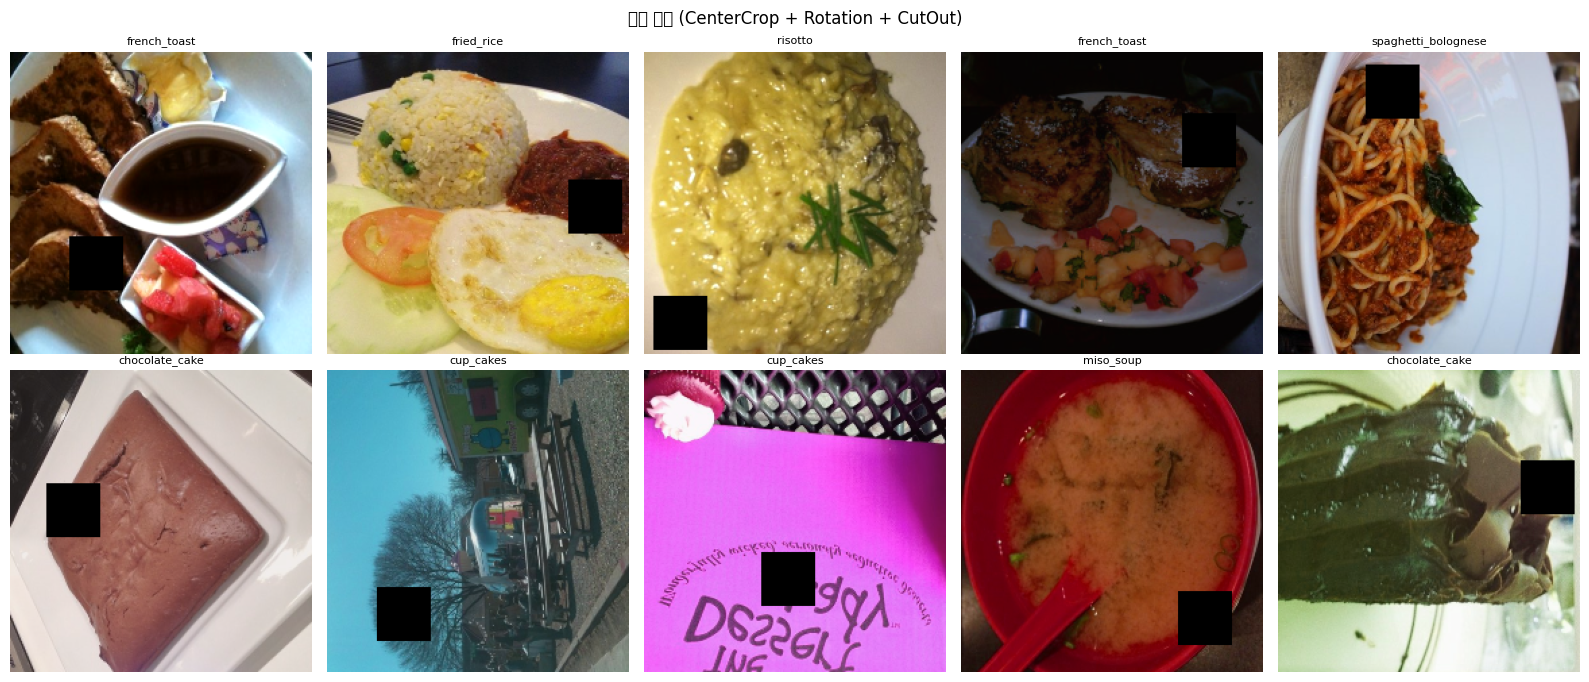

✅ 전처리 확인 완료


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


# ── CenterCrop ─────────────────────────────────────────────────
def center_crop(image):
    """Flutter copyCrop() 과 동일 로직 — 비율 유지 정사각형 자르기"""
    h         = tf.shape(image)[0]
    w         = tf.shape(image)[1]
    crop_size = tf.minimum(h, w)
    offset_h  = (h - crop_size) // 2
    offset_w  = (w - crop_size) // 2
    return tf.image.crop_to_bounding_box(image, offset_h, offset_w, crop_size, crop_size)


# ── CutOut ─────────────────────────────────────────────────────
def random_cutout(image, mask_size=40):
    """
    랜덤 영역(mask_size × mask_size)을 0으로 마스킹
    유사 클래스(스파게티 볼/카르, 라면/미소국 등) 과적합 방지
    """
    h  = IMG_SIZE
    w  = IMG_SIZE
    half = mask_size // 2

    cy = tf.random.uniform([], half, h - half, dtype=tf.int32)
    cx = tf.random.uniform([], half, w - half, dtype=tf.int32)

    y1 = cy - half
    y2 = cy + half
    x1 = cx - half
    x2 = cx + half

    # 행/열 마스크 생성 (graph-mode 호환)
    row_mask = tf.logical_and(tf.range(h) >= y1, tf.range(h) < y2)
    col_mask = tf.logical_and(tf.range(w) >= x1, tf.range(w) < x2)

    row_mask = tf.reshape(row_mask, [h, 1, 1])
    col_mask = tf.reshape(col_mask, [1, w, 1])
    patch    = tf.logical_and(row_mask, col_mask)
    patch    = tf.broadcast_to(patch, [h, w, 3])

    return tf.where(patch, tf.zeros_like(image), image)


# ── 학습 전처리 ────────────────────────────────────────────────
def preprocess_train(image, label):
    # 1. CenterCrop (비율 유지)
    image = center_crop(image)

    # 2. 리사이즈 (약간 크게 → RandomCrop)
    image = tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20])
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])

    # 3. RandomRotation — 90° 단위
    #    음식 사진은 세로/가로 촬영이 혼재 → 회전 불변성 학습
    k     = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)

    # 4. 좌우 반전
    image = tf.image.random_flip_left_right(image)

    # 5. ColorJitter
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0, 255)

    # 6. CutOut (40×40 랜덤 마스킹)
    image = random_cutout(image, mask_size=40)

    # 7. [-1, 1] 정규화 (EfficientNetV2B0 기준)
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


# ── 평가 전처리 ─────────────────────────────────────────────────
def preprocess_eval(image, label):
    # Flutter preprocess_eval() 과 동일
    image = center_crop(image)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


def build_dataset(ds, fn, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    ds = ds.map(fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if repeat:
        ds = ds.repeat()
    return ds.prefetch(AUTOTUNE)


train_ds = build_dataset(ds_train_filtered, preprocess_train, shuffle=True, repeat=True)
val_ds   = build_dataset(ds_val_filtered,   preprocess_eval)
test_ds  = build_dataset(ds_test_filtered,  preprocess_eval)

steps_per_epoch  = n_train // BATCH_SIZE
validation_steps = n_val   // BATCH_SIZE
print(f'steps_per_epoch  : {steps_per_epoch}')
print(f'validation_steps : {validation_steps}')

# 증강 결과 시각화 (역정규화)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        img_show = np.clip((images[i].numpy() + 1.0) / 2.0, 0, 1)
        ax.imshow(img_show)
        ax.set_title(SELECTED_CLASSES[labels[i].numpy()], fontsize=8)
        ax.axis('off')
plt.suptitle('증강 샘플 (CenterCrop + Rotation + CutOut)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/sample_augmented.png', dpi=100)
plt.show()
print('✅ 전처리 확인 완료')

## 6️⃣ 모델 구성 (EfficientNetV2B0)

In [ ]:
def build_model(num_classes, freeze_backbone=True):
    # ─────────────────────────────────────────────────────────
    #  EfficientNetV2B0
    #  - Fused-MBConv: MobileNetV3 Hard-Swish 문제 없음
    #  - Float16 TFLite 정확도 안정적
    #  - MobileNetV3Small 대비 정확도 +5~8%p 예상
    # ─────────────────────────────────────────────────────────
    base_model = keras.applications.EfficientNetV2B0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=False,  # 섹션5에서 직접 [-1,1] 정규화
    )
    base_model.trainable = not freeze_backbone

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x       = base_model(inputs, training=not freeze_backbone)
    x       = keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x       = keras.layers.BatchNormalization(name='bn')(x)
    x       = keras.layers.Dropout(0.3, name='dropout')(x)
    outputs = keras.layers.Dense(
        num_classes, activation='softmax', name='predictions'
    )(x)

    return keras.Model(inputs, outputs, name='efficientnetv2b0_food'), base_model


model, base_model = build_model(NUM_CLASSES, freeze_backbone=True)
model.summary()

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f'\n학습 가능: {trainable:,}  |  동결: {frozen:,}')

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "efficientnetv2b0_food"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,950,052 (22.70 MB)

 Trainable params: 28,180 (110.08 KB)

 Non-trainable params: 5,921,872 (22.59 MB)


학습 가능: 28,180  |  동결: 5,921,872


## 7️⃣ Stage 1 — 헤드 학습 (backbone 동결)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Stage 1: 헤드 학습 ===')
t0 = time.time()
history1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

=== Stage 1: 헤드 학습 ===
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 206s 418ms/step - accuracy: 0.5621 - loss: 1.5101 - val_accuracy: 0.7765 - val_loss: 0.7187
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 169s 395ms/step - accuracy: 0.6898 - loss: 1.0629 - val_accuracy: 0.8077 - val_loss: 0.6389
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 147s 392ms/step - accuracy: 0.7172 - loss: 0.9561 - val_accuracy: 0.8193 - val_loss: 0.6083
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 148s 396ms/step - accuracy: 0.7258 - loss: 0.9091 - val_accuracy: 0.8125 - val_loss: 0.6037
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 154s 410ms/step - accuracy: 0.7328 - loss: 0.8914 - val_accuracy: 0.8257 - val_loss: 0.5844
Restoring model weights from the end of the best epoch: 5.
완료 (862초)  |  최고 val_accuracy: 0.8257


## 8️⃣ Stage 2 — 전체 파인튜닝

**개선사항**
- 기존: 상위 50% 레이어만 해제
- 변경: **전체 backbone 해제** + **낮은 LR (5e-5)** + **Cosine Decay**

In [ ]:
# 전체 backbone 파인튜닝
base_model.trainable = True

trainable_now = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f'전체 학습 파라미터: {trainable_now:,}')

# Cosine Decay LR: 학습 후반부에 LR을 서서히 줄여 수렴 안정화
total_steps = STAGE2_EPOCHS * steps_per_epoch
cosine_lr   = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=STAGE2_LR,
    decay_steps=total_steps,
    alpha=1e-6,           # 최소 LR
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('\n=== Stage 2: 전체 파인튜닝 시작 ===')
t0 = time.time()
history2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='/content/best_model.keras',
            monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

전체 학습 파라미터: 5,886,884

=== Stage 2: 전체 파인튜닝 시작 ===
Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5726 - loss: 1.4451
Epoch 1: val_accuracy improved from None to 0.80605, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 272s 423ms/step - accuracy: 0.6318 - loss: 1.2282 - val_accuracy: 0.8060 - val_loss: 0.6400
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7237 - loss: 0.9008
Epoch 2: val_accuracy improved from 0.80605 to 0.83186, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 203s 412ms/step - accuracy: 0.7397 - loss: 0.8499 - val_accuracy: 0.8319 - val_loss: 0.5499
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7834 - loss: 0.7298
Epoch 3: val_accuracy improved from 0.83186 to 0.85156, saving model to /content/best_model.keras

Epoch 3: finished saving mode

/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2854/2779077493.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

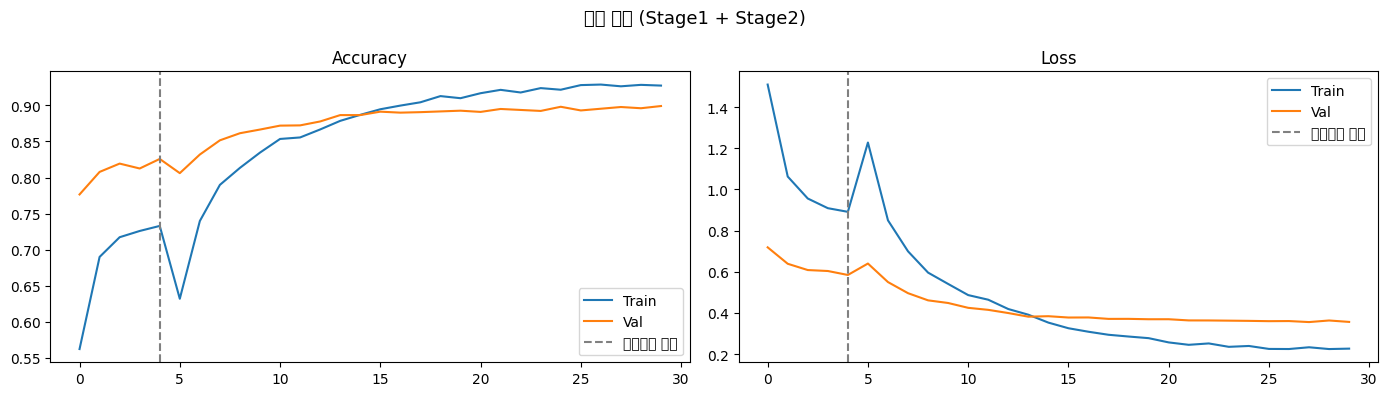

In [ ]:
# 학습 곡선
acc   = history1.history['accuracy']     + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
split = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, t, v, title in [
    (axes[0], acc,  val,   'Accuracy'),
    (axes[1], loss, vloss, 'Loss'),
]:
    ax.plot(t, label='Train')
    ax.plot(v, label='Val')
    ax.axvline(x=split - 1, color='gray', linestyle='--', label='파인튜닝 시작')
    ax.set_title(title)
    ax.legend()
plt.suptitle('학습 곡선 (Stage1 + Stage2)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

## 9️⃣ 평가 (Test Set)

In [ ]:
best_model = keras.models.load_model('/content/best_model.keras')

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\n✅ Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'   Test Loss     : {test_loss:.4f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 285ms/step - accuracy: 0.9340 - loss: 0.2264

✅ Test Accuracy : 0.9340  (93.4%)
   Test Loss     : 0.2264


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


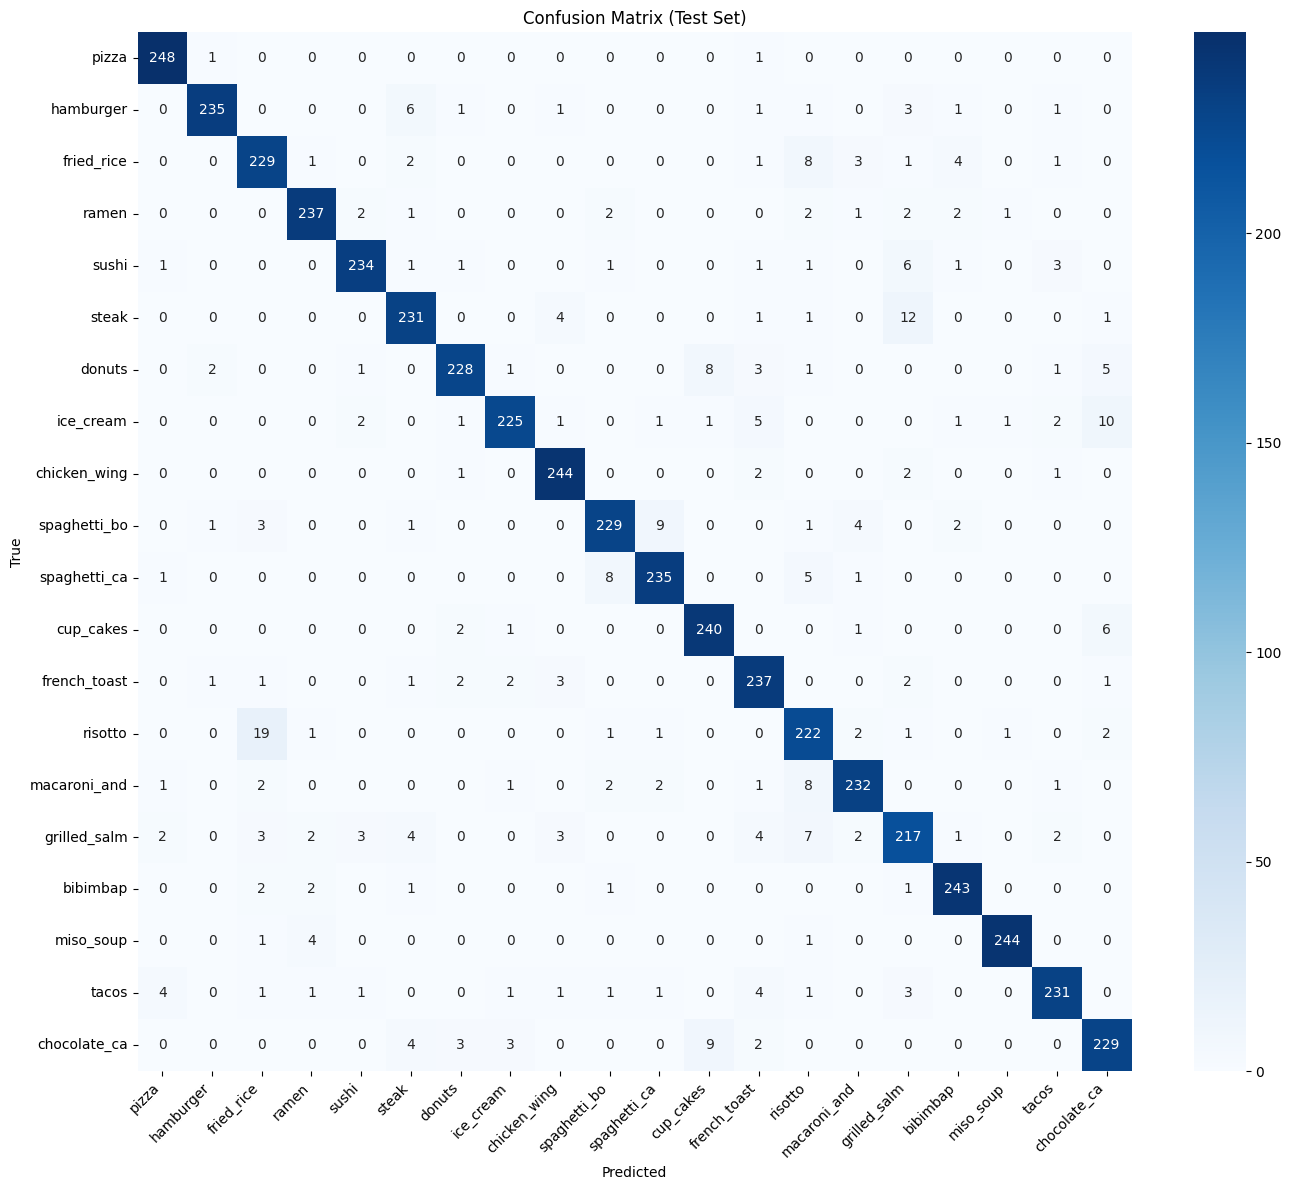

                     precision    recall  f1-score   support

              pizza       0.96      0.99      0.98       250
          hamburger       0.98      0.94      0.96       250
         fried_rice       0.88      0.92      0.90       250
              ramen       0.96      0.95      0.95       250
              sushi       0.96      0.94      0.95       250
              steak       0.92      0.92      0.92       250
             donuts       0.95      0.91      0.93       250
          ice_cream       0.96      0.90      0.93       250
      chicken_wings       0.95      0.98      0.96       250
spaghetti_bolognese       0.93      0.92      0.93       250
spaghetti_carbonara       0.94      0.94      0.94       250
          cup_cakes       0.93      0.96      0.94       250
       french_toast       0.90      0.95      0.92       250
            risotto       0.86      0.89      0.87       250
macaroni_and_cheese       0.94      0.93      0.94       250
     grilled_salmon    

In [ ]:
# Confusion Matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true      = np.array(y_true)
y_pred      = np.array(y_pred)
cm          = confusion_matrix(y_true, y_pred)
short_names = [c[:12] for c in SELECTED_CLASSES]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names
)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120)
plt.show()

print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

## 🔟 TFLite 변환 (Float16)

In [ ]:
# ─────────────────────────────────────────────────────────────
#  Float16 양자화
#  - INT8 대비 정확도 손실 최소 (~1%)
#  - EfficientNetV2의 Fused-MBConv와 궁합 좋음
#  - 크기: fp32 ~28MB → fp16 ~14MB
# ─────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

print('TFLite Float16 변환 중...')
tflite_model = converter.convert()

MODEL_PATH = '/content/efficientnetv2b0_food.tflite'
with open(MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'\n✅ TFLite 저장 완료: {size_mb:.2f} MB')

TFLite Float16 변환 중...
Saved artifact at '/tmp/tmps9kyquyf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  133516751142992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751156432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751155088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751157584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751158160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751156240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751156048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751157968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751158544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133516751158928: TensorSpec(shape=(), dtype=tf.resource, name

In [ ]:
# TFLite 정확도 검증
interp = tf.lite.Interpreter(model_path=MODEL_PATH)
interp.allocate_tensors()

inp = interp.get_input_details()
out = interp.get_output_details()
print(f'입력 shape : {inp[0]["shape"]}  dtype: {inp[0]["dtype"]}')
print(f'출력 shape : {out[0]["shape"]}  dtype: {out[0]["dtype"]}')

correct, total = 0, 0
for images, labels in test_ds.unbatch().batch(1).take(300):
    interp.set_tensor(inp[0]['index'], images.numpy())
    interp.invoke()
    pred     = np.argmax(interp.get_tensor(out[0]['index']))
    correct += int(pred == labels.numpy()[0])
    total   += 1

tflite_acc = correct / total
keras_acc  = max(history2.history['val_accuracy'])
print(f'\nKeras   val_accuracy : {keras_acc:.4f}  ({keras_acc*100:.1f}%)')
print(f'TFLite  accuracy     : {tflite_acc:.4f}  ({tflite_acc*100:.1f}%)')
print(f'정확도 차이           : {abs(keras_acc - tflite_acc)*100:.1f}%p')

입력 shape : [  1 224 224   3]  dtype: <class 'numpy.float32'>
출력 shape : [ 1 20]  dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Keras   val_accuracy : 0.8991  (89.9%)
TFLite  accuracy     : 0.9233  (92.3%)
정확도 차이           : 2.4%p


## 1️⃣1️⃣ labels.json 생성

In [ ]:
LABELS_DATA = [
    {'index': 0,  'label': 'pizza',               'name_ko': '피자'},
    {'index': 1,  'label': 'hamburger',            'name_ko': '햄버거'},
    {'index': 2,  'label': 'fried_rice',           'name_ko': '볶음밥'},
    {'index': 3,  'label': 'ramen',                'name_ko': '라면'},
    {'index': 4,  'label': 'sushi',                'name_ko': '스시'},
    {'index': 5,  'label': 'steak',                'name_ko': '스테이크'},
    {'index': 6,  'label': 'donuts',               'name_ko': '도넛'},
    {'index': 7,  'label': 'ice_cream',            'name_ko': '아이스크림'},
    {'index': 8,  'label': 'chicken_wings',        'name_ko': '치킨 윙'},
    {'index': 9,  'label': 'spaghetti_bolognese',  'name_ko': '스파게티 볼로네제'},
    {'index': 10, 'label': 'spaghetti_carbonara',  'name_ko': '스파게티 카르보나라'},
    {'index': 11, 'label': 'cup_cakes',            'name_ko': '컵케이크'},
    {'index': 12, 'label': 'french_toast',         'name_ko': '프렌치 토스트'},
    {'index': 13, 'label': 'risotto',              'name_ko': '리조또'},
    {'index': 14, 'label': 'macaroni_and_cheese',  'name_ko': '맥앤치즈'},
    {'index': 15, 'label': 'grilled_salmon',       'name_ko': '연어 구이'},
    {'index': 16, 'label': 'bibimbap',             'name_ko': '비빔밥'},
    {'index': 17, 'label': 'miso_soup',            'name_ko': '미소국'},
    {'index': 18, 'label': 'tacos',                'name_ko': '타코'},
    {'index': 19, 'label': 'chocolate_cake',       'name_ko': '초코 케이크'},
]

assert [d['label'] for d in LABELS_DATA] == SELECTED_CLASSES, '❌ 순서 불일치!'

LABELS_PATH = '/content/labels.json'
with open(LABELS_PATH, 'w', encoding='utf-8') as f:
    json.dump(LABELS_DATA, f, ensure_ascii=False, indent=2)

print('✅ labels.json 생성 완료')
print(json.dumps(LABELS_DATA, ensure_ascii=False, indent=2))

✅ labels.json 생성 완료
[
  {
    "index": 0,
    "label": "pizza",
    "name_ko": "피자"
  },
  {
    "index": 1,
    "label": "hamburger",
    "name_ko": "햄버거"
  },
  {
    "index": 2,
    "label": "fried_rice",
    "name_ko": "볶음밥"
  },
  {
    "index": 3,
    "label": "ramen",
    "name_ko": "라면"
  },
  {
    "index": 4,
    "label": "sushi",
    "name_ko": "스시"
  },
  {
    "index": 5,
    "label": "steak",
    "name_ko": "스테이크"
  },
  {
    "index": 6,
    "label": "donuts",
    "name_ko": "도넛"
  },
  {
    "index": 7,
    "label": "ice_cream",
    "name_ko": "아이스크림"
  },
  {
    "index": 8,
    "label": "chicken_wings",
    "name_ko": "치킨 윙"
  },
  {
    "index": 9,
    "label": "spaghetti_bolognese",
    "name_ko": "스파게티 볼로네제"
  },
  {
    "index": 10,
    "label": "spaghetti_carbonara",
    "name_ko": "스파게티 카르보나라"
  },
  {
    "index": 11,
    "label": "cup_cakes",
    "name_ko": "컵케이크"
  },
  {
    "index": 12,
    "label": "french_toast",
    "name_ko": "프렌치 토스트"
  },
  {
    "ind

## 1️⃣2️⃣ Drive 저장 & 다운로드

In [ ]:
files_to_save = {
    MODEL_PATH:                      'efficientnetv2b0_food.tflite',
    LABELS_PATH:                     'labels.json',
    '/content/best_model.keras':     'best_model.keras',
    '/content/training_curves.png':  'training_curves.png',
    '/content/confusion_matrix.png': 'confusion_matrix.png',
    '/content/sample_augmented.png': 'sample_augmented.png',
}

print(f'=== Drive 저장: {SAVE_DIR} ===')
for src, name in files_to_save.items():
    if os.path.exists(src):
        dst = os.path.join(SAVE_DIR, name)
        shutil.copy(src, dst)
        print(f'  ✅ {name:<45} ({os.path.getsize(dst)/1024:.1f} KB)')
    else:
        print(f'  ⚠️  {name} — 없음')

print('\n=== Flutter 배포 파일 ===')
print('  efficientnetv2b0_food.tflite  →  assets/models/')
print('  labels.json                   →  assets/models/')

=== Drive 저장: /content/drive/MyDrive/CalorieSnap_final ===
  ✅ efficientnetv2b0_food.tflite                  (11555.0 KB)
  ✅ labels.json                                   (1.6 KB)
  ✅ best_model.keras                              (70343.4 KB)
  ✅ training_curves.png                           (67.5 KB)
  ✅ confusion_matrix.png                          (162.6 KB)
  ✅ sample_augmented.png                          (1394.1 KB)

=== Flutter 배포 파일 ===
  efficientnetv2b0_food.tflite  →  assets/models/
  labels.json                   →  assets/models/


In [ ]:
from google.colab import files
files.download(MODEL_PATH)
files.download(LABELS_PATH)
print('✅ 다운로드 완료')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료
